# Stride & Seq Length Ablation - LSTM vs Transformer

Compares frame reduction strategies with seq_len=128.
All use the same AE (autoencoder_28042026_222428) and the same 500 episodes with landing frames.

In [1]:
from pathlib import Path
from datetime import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break
if STUDENT is None:
    raise RuntimeError("Could not find Student root")

FRAMES_ROOT = STUDENT / "data" / "frames"
RUNS_ROOT = STUDENT / "runs"
AE_RUN_DIR = RUNS_ROOT / "autoencoder" / "autoencoder_28042026_222428"

stamp = datetime.now().strftime("%d%m%Y_%H%M%S")
RUN_DIR = RUNS_ROOT / "sequential" / f"stride_ablation_{stamp}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Run dir:", RUN_DIR.name)

Device: mps
Run dir: stride_ablation_29042026_135849


In [2]:
Z_DIM = 64
SEQ_LEN = 128
EPOCHS = 30
LR = 3e-4
GRAD_CLIP = 1.0
BATCH_SIZE = 16  # smaller batch for longer sequences
SEED = 42
TEST_RATIO = 0.2

class AutoEncoder(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(), nn.Linear(25600, z_dim), nn.LayerNorm(z_dim))
        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, 3, 1, 1), nn.Sigmoid())
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        return self.decoder(x_hat)[:, :, :84, :84], z

ae_model = AutoEncoder(Z_DIM).to(DEVICE)
ae_model.load_state_dict(torch.load(AE_RUN_DIR / "model.pth", map_location=DEVICE))
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False

class LatentLSTM(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=z_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim),
                                  nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, z_dim))
    def forward(self, z_seq, lengths=None):
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(z_seq, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
        else:
            _, (h_n, _) = self.lstm(z_seq)
        return self.head(h_n[-1])

class LatentTransformer(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, n_heads=4, dropout=0.1, max_seq_len=128):
        super().__init__()
        self.input_proj = nn.Linear(z_dim, hidden_dim)
        self.pos_embed = nn.Embedding(max_seq_len, hidden_dim)
        layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads,
            dim_feedforward=hidden_dim * 4, dropout=dropout, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, hidden_dim),
                                  nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, z_dim))
    def forward(self, z_seq, lengths=None):
        B, T, _ = z_seq.shape
        device = z_seq.device
        x = self.input_proj(z_seq) + self.pos_embed(torch.arange(T, device=device).unsqueeze(0))
        causal = nn.Transformer.generate_square_subsequent_mask(T, device=device, dtype=x.dtype)
        pad_mask = None
        if lengths is not None:
            bm = torch.arange(T, device=device).unsqueeze(0) >= lengths.unsqueeze(1)
            pad_mask = torch.zeros_like(bm, dtype=x.dtype).masked_fill(bm, float("-inf"))
        x = self.transformer(x, mask=causal, src_key_padding_mask=pad_mask)
        if lengths is not None:
            idx = (lengths - 1).clamp(min=0).long()
        else:
            idx = torch.full((B,), T - 1, dtype=torch.long, device=device)
        return self.head(x[torch.arange(B, device=device), idx])

print("Models defined")

Models defined


## Load episodes and build datasets per strategy

In [3]:
def sim_func(prev, curr, threshold=0.01):
    prev_v = prev.reshape(-1).astype(np.float32)
    curr_v = curr.reshape(-1).astype(np.float32)
    alpha = np.dot(curr_v, prev_v) / (np.dot(prev_v, prev_v) + 1e-8)
    residual = curr_v - alpha * prev_v
    return np.linalg.norm(residual) / (np.linalg.norm(curr_v) + 1e-8) > threshold

video_dirs = sorted([p for p in FRAMES_ROOT.iterdir() if p.is_dir()], key=lambda p: int(p.name))
print(f"Loading {len(video_dirs)} episodes...")

raw_episodes = []
for vd in video_dirs:
    frames = sorted(vd.glob("*.png"), key=lambda p: int(p.stem))
    xs = [np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0 for p in frames]
    raw_episodes.append(xs)
print(f"Loaded. Mean raw length: {np.mean([len(e) for e in raw_episodes]):.0f}")

def reduce_episode(xs, skip=1, dedup_thresh=0.01):
    sub = xs[::skip]
    curr = sub[0]
    kept = [curr]
    for j in range(1, len(sub)):
        if sim_func(curr, sub[j], dedup_thresh):
            curr = sub[j]
            kept.append(curr)
    return kept

def build_chunks(episodes_reduced, seq_len, seed=42, test_ratio=0.2):
    chunks, chunk_lengths, ep_ids = [], [], []
    for ep_idx, ep in enumerate(episodes_reduced):
        t = len(ep)
        if t < 2:
            continue
        tensor = torch.tensor(np.stack(ep), dtype=torch.float32).unsqueeze(1)
        for start in range(0, t, seq_len):
            chunk = tensor[start:start + seq_len]
            valid = chunk.shape[0]
            if valid < seq_len:
                pad = torch.zeros((seq_len - valid, 1, 84, 84))
                chunk = torch.cat([chunk, pad])
            chunks.append(chunk)
            chunk_lengths.append(valid)
            ep_ids.append(ep_idx)

    x = torch.stack(chunks)
    lengths = torch.tensor(chunk_lengths, dtype=torch.int32)
    ep_ids_t = torch.tensor(ep_ids, dtype=torch.int32)

    rng = np.random.default_rng(seed)
    all_eps = np.arange(len(episodes_reduced))
    rng.shuffle(all_eps)
    n_test = int(np.ceil(test_ratio * len(episodes_reduced)))
    test_eps = set(all_eps[:n_test].tolist())
    train_mask = torch.tensor([int(e.item()) not in test_eps for e in ep_ids_t])

    train_ds = TensorDataset(x[train_mask], lengths[train_mask])
    test_ds = TensorDataset(x[~train_mask], lengths[~train_mask])
    return train_ds, test_ds

strategies = {
    "current (dedup 0.01)": {"skip": 1, "thresh": 0.01},
    "every 2nd + dedup 0.01": {"skip": 2, "thresh": 0.01},
    "every 3rd + dedup 0.01": {"skip": 3, "thresh": 0.01},
    "every 3rd + dedup 0.03": {"skip": 3, "thresh": 0.03},
}

datasets = {}
for name, params in strategies.items():
    reduced = [reduce_episode(ep, skip=params["skip"], dedup_thresh=params["thresh"]) for ep in raw_episodes]
    mean_len = np.mean([len(e) for e in reduced])
    train_ds, test_ds = build_chunks(reduced, SEQ_LEN)
    datasets[name] = (train_ds, test_ds)
    coverage = min(SEQ_LEN / mean_len * 100, 100)
    print(f"{name:30s}: mean {mean_len:.0f} frames/ep, {len(train_ds)} train / {len(test_ds)} test chunks, seq covers ~{coverage:.0f}%")

Loading 500 episodes...


Loaded. Mean raw length: 329


current (dedup 0.01)          : mean 229 frames/ep, 895 train / 224 test chunks, seq covers ~56%


every 2nd + dedup 0.01        : mean 127 frames/ep, 573 train / 147 test chunks, seq covers ~100%


every 3rd + dedup 0.01        : mean 88 frames/ep, 411 train / 104 test chunks, seq covers ~100%


every 3rd + dedup 0.03        : mean 56 frames/ep, 400 train / 100 test chunks, seq covers ~100%


## Train all configurations

In [4]:
def train_model(model, train_loader, test_loader, name, epochs=EPOCHS):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    train_losses, test_losses = [], []
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss, n_b = 0.0, 0
        for batch in train_loader:
            bx, blens = batch[0].to(DEVICE), batch[1].to(DEVICE)
            z_in, z_tgt = [], []
            with torch.no_grad():
                for i in range(bx.shape[0]):
                    sl = int(blens[i].item())
                    if sl < 2: continue
                    xv = bx[i:i+1, :sl]
                    zl = [ae_model(xv[:, t])[1] for t in range(sl - 1)]
                    z_in.append(torch.stack(zl, dim=1).squeeze(0))
                    z_tgt.append(ae_model(xv[:, -1])[1].squeeze(0))
            if not z_in: continue
            il = torch.tensor([z.shape[0] for z in z_in], dtype=torch.int64, device=DEVICE)
            ml = int(il.max().item())
            padded = [torch.cat([z, torch.zeros(ml - z.shape[0], z.shape[1], device=DEVICE)]) if z.shape[0] < ml else z for z in z_in]
            pred = model(torch.stack(padded), lengths=il)
            loss = F.mse_loss(pred, torch.stack(z_tgt))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item(); n_b += 1

        model.eval()
        te_loss, te_nb = 0.0, 0
        with torch.no_grad():
            for batch in test_loader:
                bx, blens = batch[0].to(DEVICE), batch[1].to(DEVICE)
                z_in, z_tgt = [], []
                for i in range(bx.shape[0]):
                    sl = int(blens[i].item())
                    if sl < 2: continue
                    xv = bx[i:i+1, :sl]
                    zl = [ae_model(xv[:, t])[1] for t in range(sl - 1)]
                    z_in.append(torch.stack(zl, dim=1).squeeze(0))
                    z_tgt.append(ae_model(xv[:, -1])[1].squeeze(0))
                if not z_in: continue
                il = torch.tensor([z.shape[0] for z in z_in], dtype=torch.int64, device=DEVICE)
                ml = int(il.max().item())
                padded = [torch.cat([z, torch.zeros(ml - z.shape[0], z.shape[1], device=DEVICE)]) if z.shape[0] < ml else z for z in z_in]
                pred = model(torch.stack(padded), lengths=il)
                te_loss += F.mse_loss(pred, torch.stack(z_tgt)).item(); te_nb += 1

        tr_mean = ep_loss / max(n_b, 1)
        te_mean = te_loss / max(te_nb, 1)
        train_losses.append(tr_mean)
        test_losses.append(te_mean)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{name}] ep {epoch:02d}/{epochs} train {tr_mean:.6f} test {te_mean:.6f} | {time.time()-t0:.1f}s")

    return train_losses, test_losses

all_results = {}

for strat_name, (train_ds, test_ds) in datasets.items():
    train_loader = DataLoader(train_ds, shuffle=True, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_ds, shuffle=False, batch_size=BATCH_SIZE)

    print(f"\n{'='*60}")
    print(f"  {strat_name} - LSTM")
    print(f"{'='*60}")
    lstm = LatentLSTM(Z_DIM).to(DEVICE)
    lstm_tr, lstm_te = train_model(lstm, train_loader, test_loader, "LSTM")

    print(f"\n{'='*60}")
    print(f"  {strat_name} - Transformer")
    print(f"{'='*60}")
    tf = LatentTransformer(Z_DIM, max_seq_len=SEQ_LEN).to(DEVICE)
    tf_tr, tf_te = train_model(tf, train_loader, test_loader, "TF")

    all_results[strat_name] = {
        "lstm_train": lstm_tr, "lstm_test": lstm_te,
        "tf_train": tf_tr, "tf_test": tf_te,
    }
    print(f"\n  {strat_name} FINAL - LSTM test: {lstm_te[-1]:.6f}, TF test: {tf_te[-1]:.6f}")


  current (dedup 0.01) - LSTM


  [LSTM] ep 01/30 train 0.341678 test 0.073533 | 104.9s


  [LSTM] ep 05/30 train 0.037023 test 0.014032 | 550.9s


  [LSTM] ep 10/30 train 0.024627 test 0.009583 | 1084.5s


  [LSTM] ep 15/30 train 0.019777 test 0.008221 | 1606.6s


...

  [TF] ep 10/30 train 0.043461 test 0.026505 | 288.5s


  [TF] ep 15/30 train 0.033206 test 0.019964 | 435.8s


  [TF] ep 20/30 train 0.028271 test 0.017272 | 573.0s


  [TF] ep 25/30 train 0.025013 test 0.015082 | 700.0s


  [TF] ep 30/30 train 0.023799 test 0.014297 | 823.8s

  every 3rd + dedup 0.03 FINAL - LSTM test: 0.007296, TF test: 0.014297


## Results

In [5]:
print(f"{'Strategy':35s} {'LSTM test':>12s} {'TF test':>12s} {'Winner':>10s}")
print("-" * 75)
for name in strategies:
    r = all_results[name]
    lt = r["lstm_test"][-1]
    tt = r["tf_test"][-1]
    winner = "LSTM" if lt < tt else "TF"
    print(f"{name:35s} {lt:>12.6f} {tt:>12.6f} {winner:>10s}")

Strategy                               LSTM test      TF test     Winner
---------------------------------------------------------------------------
current (dedup 0.01)                    0.005785     0.010696       LSTM
every 2nd + dedup 0.01                  0.007167     0.013680       LSTM
every 3rd + dedup 0.01                  0.006994     0.014727       LSTM
every 3rd + dedup 0.03                  0.007296     0.014297       LSTM


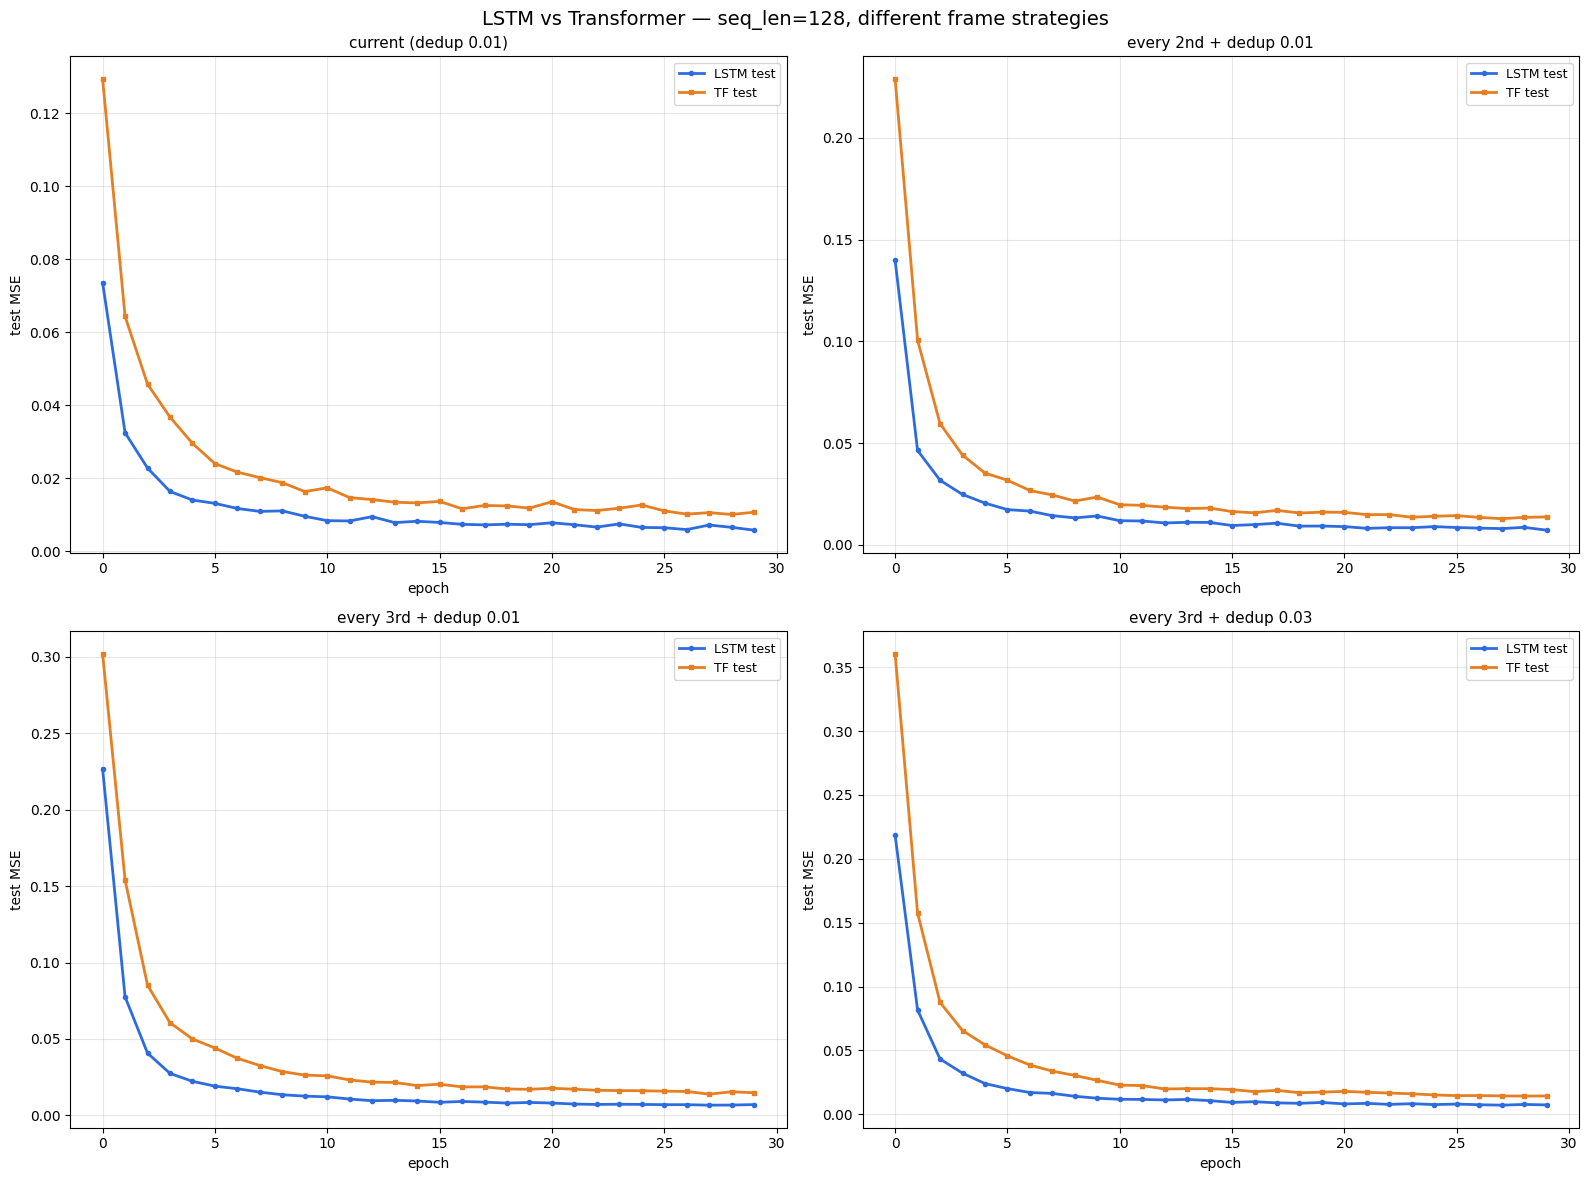

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, r) in enumerate(all_results.items()):
    ax = axes[idx]
    ax.plot(r["lstm_test"], 'o-', lw=2, label="LSTM test", color="#2d6cdf", markersize=3)
    ax.plot(r["tf_test"], 's-', lw=2, label="TF test", color="#e67e22", markersize=3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("epoch")
    ax.set_ylabel("test MSE")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"LSTM vs Transformer - seq_len={SEQ_LEN}, different frame strategies", fontsize=14)
plt.tight_layout()
plt.savefig(RUN_DIR / "stride_ablation.png", dpi=150)
plt.show()

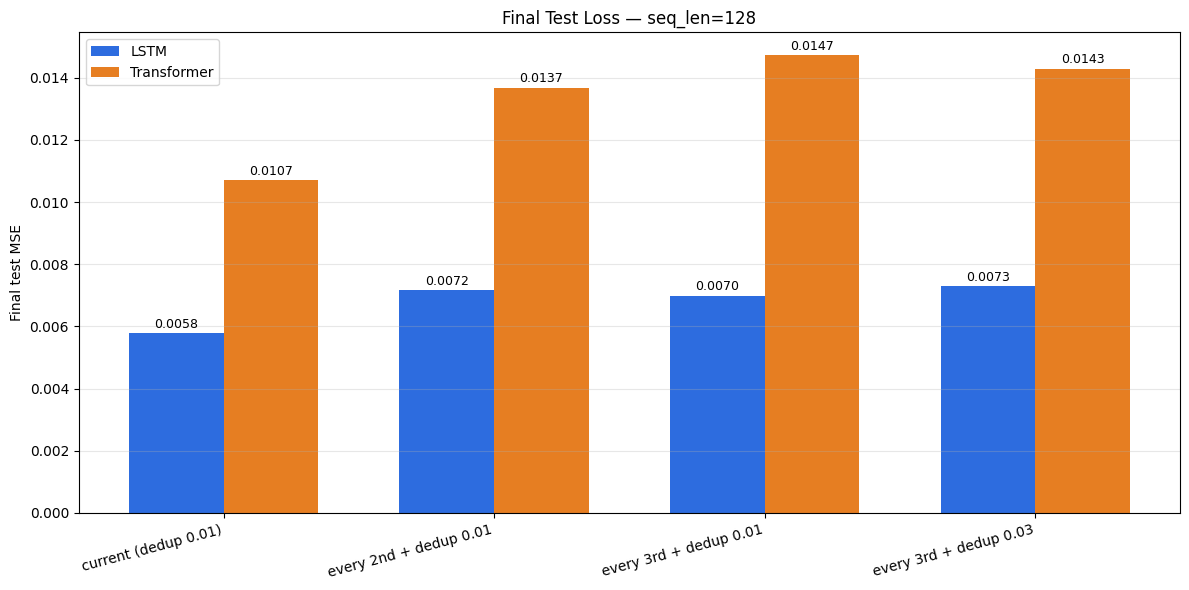

In [7]:
# Bar chart of final test losses
strat_names = list(all_results.keys())
lstm_finals = [all_results[n]["lstm_test"][-1] for n in strat_names]
tf_finals = [all_results[n]["tf_test"][-1] for n in strat_names]

x = np.arange(len(strat_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lstm_finals, width, label="LSTM", color="#2d6cdf")
bars2 = ax.bar(x + width/2, tf_finals, width, label="Transformer", color="#e67e22")

ax.set_ylabel("Final test MSE")
ax.set_title(f"Final Test Loss - seq_len={SEQ_LEN}")
ax.set_xticks(x)
ax.set_xticklabels(strat_names, rotation=15, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(RUN_DIR / "stride_ablation_bars.png", dpi=150)
plt.show()

In [8]:
torch.save(all_results, RUN_DIR / "results.pt")
print(f"Saved to {RUN_DIR}")

Saved to /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/sequential/stride_ablation_29042026_135849
